# Datamesh - quickstart

A minimal, end-to-end introduction to [Oceanum Datamesh](https://oceanum.io) using the
`oceanum` Python library.

**What you will do**

1. Connect to Datamesh
2. Browse the catalogue of available datasets
3. Inspect one dataset
4. Download a small slice of data
5. Plot it

## 1. Connect

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cmocean as cmo
import xarray as xr

from pathlib import Path
from oceanum.datamesh import Connector

In [2]:
TOKEN = (Path.home() / ".datamesh_token").read_text().strip()
datamesh = Connector(token=TOKEN)
print("Connected to", datamesh.host)

Connected to datamesh.oceanum.io


## 2. Browse the catalogue

`get_catalog()` lists every dataset your token can see. It behaves like a read-only
dictionary keyed by dataset id.

In [3]:
cat = datamesh.get_catalog()

print(f"You have access to {len(cat)} datasets\n")
print(cat)

You have access to 40 datasets

Datamesh catalog with 40 datasources:
 ECMWF IFS mean sea level pressure forecast [ecmwf_msl_0p25]
 Gebco 2026 15-sec global bathymetry [gebco_2026]
 CMEMS Level 4 Daily Global Ocean sea and ice surface temperature from ESA SST CCI observation reprocessing [esacci-glo-sst-l4-rep-obs-sst]
 ECMWF IFS 10m wind forecast [ecmwf_wind10m_0p25]
 DEMO Oceanum global ERA5 wave hindcast parameters [oceanum_wave_glob05_era5_v1_grid_demo]
 ECMWF IFS total precipitation forecast [ecmwf_tp_0p25]
 MOANAPROJECT - Mangopare sensor deployments [moana-project-sensors]
 ECMWF 0.25° 3/6-hourly IFS Global deterministic forecast single-level fields [ecmwf_ifs_0p25_oper_sfc]
 ECMWF 0.25° 3/6-hourly IFS Global deterministic forecast single-level fields, 2024 archive (IFS 48r1) [ecmwf_ifs_0p25_oper_sfc_2024]
 ECMWF IFS 2m temperature forecast [ecmwf_t2m_0p25]
 NOAA ACSPO L3S-LEO AM night-time SST, global 0.02°, from 2006 (PO.DAAC) [noaa-acspo-l3s-leo-am-night-podaac]
 NOAA ACSPO L

### Narrow it down

The first argument is a free-text search over name, description and tags.
You can also search a specific tag with the `tags:` prefix.

In [20]:
print(datamesh.get_catalog("GLORYS12"))

Datamesh catalog with 26 datasources:
 La Paz Bay - Fishing vessel data [la_paz_bay_fv_nrt]
 Okinka - Guinea-Bissau - Fishing Vessel Data [okina_fv_nrt]
 MOANAPROJECT - Mangopare sensor deployments [moana-project-sensors]
 NOAA ACSPO L3S-LEO AM day-time SST, global 0.02°, near real time [noaa-acspo-l3s-leo-am-day-nrt]
 Otis global constituents tpxo9 v5a [tpxo9_v5a_cons]
 Argo Float Measurements [argo_floats]
 Profile data from the Fishing Vessel Ocean Observing Network [fvon_profile_fv_nrt]
 DEMO Oceanum global ERA5 wave hindcast parameters [oceanum_wave_glob05_era5_v1_grid_demo]
 CMEMS Mean dynamic topography from Global Ocean Physics Analysis and Forecast [cmems_mod_glo_phy_anfc_0-083deg_static-static-arco]
 Oceanum tide constituents New Zealand 2 km [oceanum_tide_cons_nz_2km]
 CMEMS Mean dynamic topography from Global Ocean Physics Reanalysis [cmems_mod_glo_phy_my_0-083deg_static-static-arco]
 Otis global constituents tpxo9 atlas v5 [tpxo9_atlas_v5_cons]
 North Atlantic Arc Project 

In [5]:
print(datamesh.get_catalog("tags:bathymetry"))

Datamesh catalog with 1 datasources:
 Gebco 2026 15-sec global bathymetry [gebco_2026]


You can also filter by time and by area:

```python
datamesh.get_catalog(timefilter=["2020-01-01", "2021-01-01"])
datamesh.get_catalog(geofilter=shapely.geometry.box(165, -48, 180, -34))
```

In [21]:

import shapely

search = "temperature"
bbox = shapely.geometry.box(161, -51, 185, -31)

cat = (datamesh.get_catalog(geofilter=bbox, search = search))   
print(cat) 

#print(datamesh.get_catalog("tags:temperature"))

Datamesh catalog with 36 datasources:
 NOAA ACSPO L3S-LEO AM day-time SST, global 0.02°, near real time [noaa-acspo-l3s-leo-am-day-nrt]
 ECMWF IFS 2m temperature forecast [ecmwf_t2m_0p25]
 ECMWF ERA5 global 2m temperature hindcast [era5_temp2m]
 Argo Float Measurements [argo_floats]
 MOANAPROJECT - Mangopare sensor deployments [moana-project-sensors]
 CMEMS Mean dynamic topography from Global Ocean Physics Analysis and Forecast [cmems_mod_glo_phy_anfc_0-083deg_static-static-arco]
 CMEMS Mean dynamic topography from Global Ocean Physics Reanalysis [cmems_mod_glo_phy_my_0-083deg_static-static-arco]
 CMEMS 6-hourly instantaneous sea water temperature from Global Ocean Physics Analysis and Forecast [cmems_mod_glo_phy-thetao_anfc_0-083deg_pt6h-i]
 NOAA ACSPO L3S-LEO PM day-time SST, global 0.02°, near real time [noaa-acspo-l3s-leo-pm-day-nrt]
 NOAA ACSPO L3S-LEO AM night-time SST, global 0.02°, from 2006 (PO.DAAC) [noaa-acspo-l3s-leo-am-night-podaac]
 NOAA ACSPO L3S-LEO AM day-time SST, glo

In [ ]:
cat.keys()


['noaa-acspo-l3s-leo-am-day-nrt',
 'ecmwf_t2m_0p25',
 'era5_temp2m',
 'argo_floats',
 'moana-project-sensors',
 'cmems_mod_glo_phy_anfc_0-083deg_static-static-arco',
 'cmems_mod_glo_phy_my_0-083deg_static-static-arco',
 'cmems_mod_glo_phy-thetao_anfc_0-083deg_pt6h-i',
 'noaa-acspo-l3s-leo-pm-day-nrt',
 'noaa-acspo-l3s-leo-am-night-podaac',
 'noaa-acspo-l3s-leo-am-day-podaac',
 'noaa-acspo-l3s-leo-pm-night-podaac',
 'noaa-acspo-l3s-leo-pm-day-podaac',
 'noaa-acspo-l3s-leo-am-night-nrt',
 'noaa-acspo-l3s-leo-pm-night-nrt',
 'cmems_mod_glo_phy_anfc_0-083deg_pt1h-m',
 'era5_precip_rate',
 'ecmwf_cape_0p25',
 'era5_mslp',
 'ecmwf_tprate_0p25',
 'era5_wind10m',
 'metoffice-glo-sst-l4-nrt-obs-sst-v2',
 'oceanum_wave_glob05_era5_v1_grid_demo',
 'esacci-glo-sst-l4-rep-obs-sst',
 'ecmwf_tp_0p25',
 'tpxo9_v5a_cons',
 'ecmwf_msl_0p25',
 'ecmwf_wind10m_0p25',
 'ecmwf_wind10m_0p25_nowcast',
 'cmems_mod_glo_phy-so_anfc_0-083deg_pt6h-i',
 'fvon_profile_fv_nrt',
 'gebco_2026',
 'ecmwf_ifs_0p25_oper_sfc

In [25]:
cat.keys()[15]

'cmems_mod_glo_phy_anfc_0-083deg_pt1h-m'

## 3. Inspect a dataset

Pick one dataset and look at it *before* downloading anything. `get_datasource()` only
fetches metadata — it does not move any data.

We will use a small demo dataset: one year (2020) of global wave hindcast at 0.5 degrees.

In [26]:
DATASET = cat.keys()[15]

dsrc = datamesh.get_datasource(DATASET)
print(dsrc)

print("Time range :", dsrc.tstart, "->", dsrc.tend)
print("Bounds     :", dsrc.bounds)
print("Coordinates:", dsrc.coordinates)
print()
print("Grid size:")
for dim, size in dsrc.dataschema.model_dump()["dims"].items():
    print(f"  {dim}: {size}")


        CMEMS Hourly mean fields from Global Ocean Physics Analysis and Forecast [cmems_mod_glo_phy_anfc_0-083deg_pt1h-m]
            Extent: (-180.0, -80.0, 179.91668701171875, 90.0)
            Timerange: 2022-06-01 00:00:00+00:00 to Now
            10 attributes
            5 variables
        
Time range : 2022-06-01 00:00:00+00:00 -> None
Bounds     : (-180.0, -80.0, 179.91668701171875, 90.0)
Coordinates: {'t': 'time', 'x': 'longitude', 'y': 'latitude', 'z': 'elevation'}

Grid size:
  time: 38328
  latitude: 2041
  elevation: 1
  longitude: 4320


In [27]:
# The variables available in this dataset
for name in list(dsrc.variables)[:15]:
    print(name)
print("...")
print(f"\n{len(dsrc.variables)} variables in total")

# Fix your ID corresponding to the variable 
variable = list(dsrc.variables)[0] 
print(variable)

so
uo
vo
zos
thetao
...

5 variables in total
so


The key ones for waves:

| Variable | Meaning | Units |
|---|---|---|
| `hs`  | significant wave height | m |
| `tp`  | peak period | s |
| `dp`  | peak direction | degrees |
| `dir` | mean direction | degrees |
| `spr` | directional spread | degrees |
| `uwnd`, `vwnd` | 10 m wind components | m/s |

> **Watch out:** this dataset uses **longitude 0-360**, not -180/180. A point at 20 W is
> `340`, not `-20`. Check `dsrc.bounds` whenever you use a new dataset.

## 4. Download a small slice

This is the important habit: **never load a whole gridded dataset**. Use `query()` so
Datamesh does the subsetting on the server and only sends you what you asked for.

Here we take one day, one variable, over New Zealand.

In [28]:
print(bbox)

POLYGON ((185 -51, 185 -31, 161 -31, 161 -51, 185 -51))


In [29]:
dsrc = datamesh.get_datasource(DATASET)
print(dsrc.bounds)
print(dsrc.variables)

(-180.0, -80.0, 179.91668701171875, 90.0)
{'so': {'dims': ['time', 'elevation', 'latitude', 'longitude'], 'attrs': {'units': '1e-3', 'long_name': 'sea surface salinity', 'unit_long': 'Practical Salinity Unit', 'valid_max': 50.0, 'valid_min': 0.0, 'cell_methods': 'area: mean', 'standard_name': 'sea_water_salinity'}, 'dtype': 'float32', 'shape': [38328, 1, 2041, 4320]}, 'uo': {'dims': ['time', 'elevation', 'latitude', 'longitude'], 'attrs': {'units': 'm s-1', 'long_name': 'Eastward surface velocity', 'unit_long': 'Meters per second', 'valid_max': 10.0, 'valid_min': -10.0, 'cell_methods': 'area: mean', 'standard_name': 'eastward_sea_water_velocity'}, 'dtype': 'float32', 'shape': [38328, 1, 2041, 4320]}, 'vo': {'dims': ['time', 'elevation', 'latitude', 'longitude'], 'attrs': {'units': 'm s-1', 'long_name': 'Northward surface velocity', 'unit_long': 'Meters per second', 'valid_max': 10.0, 'valid_min': -10.0, 'cell_methods': 'area: mean', 'standard_name': 'northward_sea_water_velocity'}, 'dt

In [31]:
ds = datamesh.query(
    datasource=DATASET,
    variables= ["thetao"],
    timefilter={"type": "range", "times": ["2022-06-01", "2022-07-01"]},
    geofilter={"type": "bbox", "geom": [161, -51, 185, -31]},   # [161, -51, 185, -31]
)

ds

<xarray.Dataset> Size: 158MB
Dimensions:    (time: 721, elevation: 1, latitude: 241, longitude: 228)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2022-06-01 ... 2022-07-01
  * elevation  (elevation) float32 4B -0.494
  * latitude   (latitude) float32 964B -51.0 -50.92 -50.83 ... -31.08 -31.0
  * longitude  (longitude) float32 912B 161.0 161.1 161.2 ... 179.8 179.8 179.9
Data variables:
    thetao     (time, elevation, latitude, longitude) float32 158MB 9.448 ......
Attributes: (12/13)
    Conventions:           CF-1.8
    _coordinates:          {"t":"time","x":"longitude","y":"latitude","z":"el...
    _datamesh_cache_hash:  12c12bd7350a98cee0b71243c9909b8e939b0ac6b7788b60cc...
    _request_size:         158477680
    area:                  Global
    contact:               https://marine.copernicus.eu/contact
    ...                    ...
    institution:           Mercator Ocean International
    licence:               http://marine.copernicus.eu/services-portfolio/ser...
    producer:              CMEMS - Global Monitoring and Forecasting Centre
    references:            http://marine.copernicus.eu
    source:                MOI GLO12
    title:                 hourly mean fields from Global Ocean Physics Analy...

In [32]:
ds.thetao

<xarray.DataArray 'thetao' (time: 721, elevation: 1, latitude: 241,
                            longitude: 228)> Size: 158MB
array([[[[ 9.447689 ,  9.31961  ,  9.269142 , ...,  7.6043277,
           7.5981326,  7.5799747],
         [10.0252285,  9.927336 ,  9.845427 , ...,  7.610415 ,
           7.6105404,  7.626993 ],
         [10.122884 , 10.097381 , 10.073778 , ...,  7.6186385,
           7.6479735,  7.743863 ],
         ...,
         [20.591131 , 20.56633  , 20.541586 , ..., 20.593767 ,
          20.63043  , 20.638813 ],
         [20.63937  , 20.639364 , 20.635098 , ..., 20.772282 ,
          20.775732 , 20.757437 ],
         [20.701477 , 20.697779 , 20.690083 , ..., 20.864773 ,
          20.836943 , 20.807032 ]]],


       [[[ 9.448902 ,  9.309956 ,  9.248139 , ...,  7.606037 ,
           7.599583 ,  7.581625 ],
         [10.027473 ,  9.927077 ,  9.840022 , ...,  7.61235  ,
           7.612951 ,  7.6321564],
         [10.122107 , 10.096168 , 10.071881 , ...,  7.6216655,
...
         [18.684452 , 18.680412 , 18.680922 , ..., 18.91238  ,
          18.887608 , 18.85841  ],
         [18.695198 , 18.685488 , 18.69135  , ..., 18.901514 ,
          18.888674 , 18.86142  ]]],


       [[[ 8.2644615,  8.580186 ,  8.783201 , ...,  7.338138 ,
           7.3376436,  7.3219986],
         [ 8.3737755,  8.299369 ,  8.5199175, ...,  7.3185086,
           7.309747 ,  7.3109818],
         [ 8.753099 ,  8.548934 ,  8.407964 , ...,  7.317037 ,
           7.308354 ,  7.291147 ],
         ...,
         [18.715853 , 18.717718 , 18.72607  , ..., 18.922869 ,
          18.900555 , 18.85739  ],
         [18.700432 , 18.693724 , 18.69208  , ..., 18.92004  ,
          18.895712 , 18.866365 ],
         [18.711817 , 18.699324 , 18.702538 , ..., 18.911573 ,
          18.897854 , 18.870533 ]]]],
      shape=(721, 1, 241, 228), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2022-06-01 ... 2022-07-01
  * elevation  (elevation) float32 4B -0.494
  * latitude   (latitude) float32 964B -51.0 -50.92 -50.83 ... -31.08 -31.0
  * longitude  (longitude) float32 912B 161.0 161.1 161.2 ... 179.8 179.8 179.9
Attributes:
    cell_methods:   area: mean
    long_name:      sea_surface_temperature
    standard_name:  sea_water_potential_temperature
    unit_long:      Degrees Celsius
    units:          degrees_C
    valid_max:      40.0
    valid_min:      -10.0

## 5. Plot it

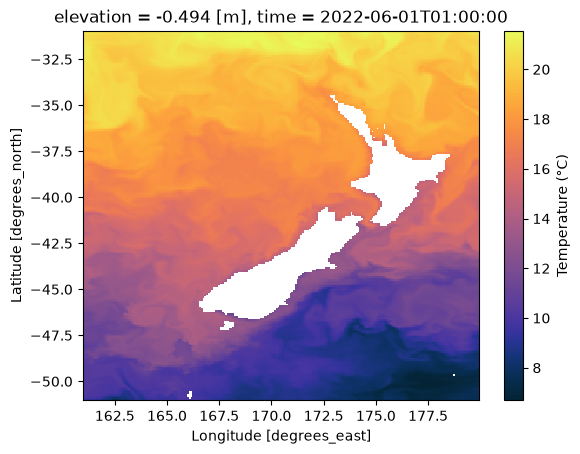

In [33]:

ds.thetao.isel(time=1, elevation=-1).plot(x="longitude", y="latitude", cmap=cmo.cm.thermal, cbar_kwargs={"label": "Temperature (°C)"})


## That is the whole workflow

```
get_catalog()    ->  what is available
get_datasource() ->  what is inside it
query()          ->  the slice you actually need
```

**Next:** `02_timeseries_at_a_point.ipynb` — how to pull a time series at a single
location, which is the most common request.

**Reference**
- Python docs: <https://oceanum-python.readthedocs.io/en/latest/>
- Dataset catalogue: <https://datasets.oceanum.io>